# Rede de indicadores ODS — Santa Catarina

Fluxo analítico do capítulo 4 (Procedimentos Metodológicos) da versão enviada à banca.

1. Recorte de SC e cobertura mínima de 57% → 53 indicadores
2. Média municipal (sem padronização) → matriz 295 × 53
3. Spearman para os 1.378 pares; aresta quando |r| ≥ 0,3 e p < 0,05
4. Rede: componentes, nós isolados, grau e intermediação
5. Louvain (100 sementes) com NMI
6. Comparação com 1.000 redes Erdős–Rényi
7. Teste de sensibilidade do limite de cobertura
8. Visualização da rede (prova de conceito) e exportação

## 0. Ambiente

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install python-louvain pyvis -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 52.3 MB/s eta 0:00:00


In [3]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import networkx as nx
from scipy import stats
from sklearn.metrics import normalized_mutual_info_score
import community as community_louvain

# caminhos
BASE = '/content/drive/MyDrive/Mestrado/bkp/base_dados'
OUTPUT = '/content/drive/MyDrive/Mestrado/outputs'
os.makedirs(OUTPUT, exist_ok=True)

# parâmetros do capítulo 4
COBERTURA_MIN = 0.57
R_MIN = 0.3
P_MAX = 0.05
N_LOUVAIN = 100
N_ALEATORIAS = 1000
SEED_LAYOUT = 42

# cores oficiais dos ODS
CORES_ODS = {
    1: '#E5243B', 2: '#DDA63A', 3: '#4C9F38', 4: '#C5192D', 5: '#FF3A21',
    6: '#26BDE2', 7: '#FCC30B', 8: '#A21942', 9: '#FD6925', 10: '#DD1367',
    11: '#FD9D24', 12: '#BF8B2E', 13: '#3F7E44', 14: '#0A97D9', 15: '#56C02B',
    16: '#00689D', 17: '#19486A'
}
COR_POSITIVA = '#2166ac'
COR_NEGATIVA = '#b2182b'

## 1. Dados e recorte de Santa Catarina

In [4]:
df = pd.read_excel(f'{BASE}/base_dados_idsc_sc.xlsx', sheet_name='series_temporais')
df_dict = pd.read_excel(f'{BASE}/dicionario_indicadores.xlsx')

print(f'Base nacional: {df.shape}')
print(f'Dicionário: {df_dict.shape}')

# atalhos para metadados dos indicadores
ods_de = dict(zip(df_dict['Arquivo'], df_dict['ODS'].astype(int)))
nome_de = dict(zip(df_dict['Arquivo'], df_dict['Indicador']))

Base nacional: (77982, 102)
Dicionário: (100, 4)


In [5]:
# filtrar SC pelo prefixo 42 do código IBGE
df_sc = df[df['ID'].astype(str).str.startswith('42')].copy()

print(f'Municípios: {df_sc["ID"].nunique()}')
print(f'Anos presentes: {sorted(int(a) for a in df_sc["ANO"].unique())}')
print(f'Registros município-ano: {len(df_sc)}')

Municípios: 295
Anos presentes: [2010, 2012, 2013, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Registros município-ano: 4130


## 2. Cobertura e seleção dos indicadores (limite operacional de 57%)

Indicadores iniciais: 100
Indicadores selecionados: 53
Primeiro abaixo do limite: SDG10_20_MINF (54.38%)
Seguinte: SDG8_2_PIB_CPT (35.71%)


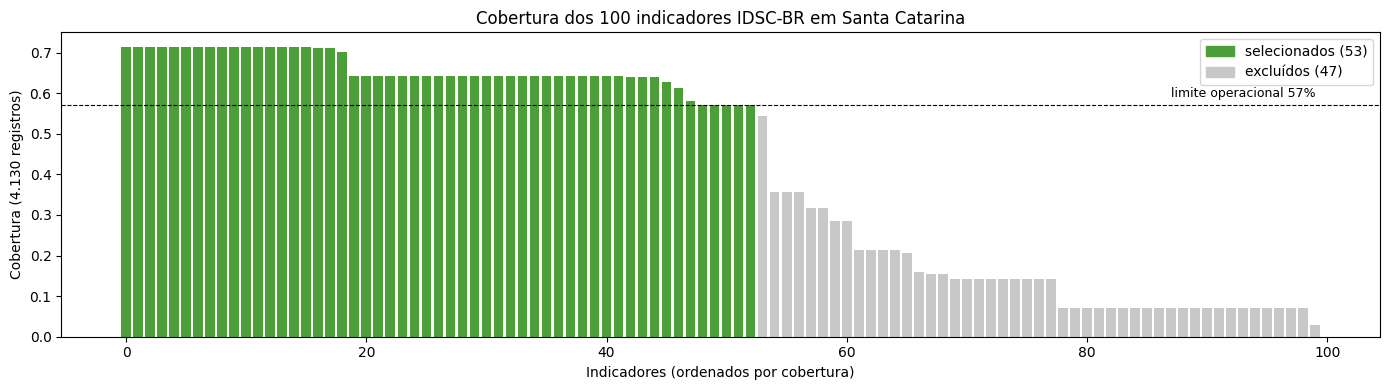

In [6]:
indicadores = [c for c in df_sc.columns if c not in ['ID', 'ANO']]

cobertura = (df_sc[indicadores]
             .notna()
             .mean()
             .rename('cobertura')
             .rename_axis('Arquivo')
             .reset_index())
cobertura['ODS'] = cobertura['Arquivo'].map(ods_de)
cobertura['Indicador'] = cobertura['Arquivo'].map(nome_de)
cobertura = cobertura.sort_values('cobertura', ascending=False).reset_index(drop=True)
cobertura['selecionado'] = cobertura['cobertura'] >= COBERTURA_MIN

indicadores_validos = cobertura.loc[cobertura['selecionado'], 'Arquivo'].tolist()
excluidos = cobertura[~cobertura['selecionado']]

# indicador mais próximo do limite, usado no teste de sensibilidade (seção 7)
fronteira = excluidos.iloc[0]

print(f'Indicadores iniciais: {len(indicadores)}')
print(f'Indicadores selecionados: {len(indicadores_validos)}')
print(f'Primeiro abaixo do limite: {fronteira["Arquivo"]} ({fronteira["cobertura"]:.2%})')
print(f'Seguinte: {excluidos.iloc[1]["Arquivo"]} ({excluidos.iloc[1]["cobertura"]:.2%})')

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(cobertura)), cobertura['cobertura'],
       color=np.where(cobertura['selecionado'], '#4C9F38', '#c8c8c8'))
ax.axhline(COBERTURA_MIN, color='black', linestyle='--', linewidth=0.8)
ax.text(len(cobertura) - 1, COBERTURA_MIN + 0.02, 'limite operacional 57%', ha='right', fontsize=9)
ax.set_xlabel('Indicadores (ordenados por cobertura)')
ax.set_ylabel('Cobertura (4.130 registros)')
ax.set_title('Cobertura dos 100 indicadores IDSC-BR em Santa Catarina')
ax.legend(handles=[Patch(color='#4C9F38', label=f'selecionados ({len(indicadores_validos)})'),
                   Patch(color='#c8c8c8', label=f'excluídos ({len(excluidos)})')])
plt.tight_layout()
plt.savefig(f'{OUTPUT}/fig_cobertura.png', dpi=300)
plt.show()

In [7]:
# representação dos ODS após a seleção (ODS 18 não integra a base)
rep_ods = (cobertura[cobertura['selecionado']]
           .groupby('ODS').size()
           .reindex(range(1, 18), fill_value=0))

print(rep_ods.to_string())
print(f'\nODS sem indicadores: {rep_ods[rep_ods == 0].index.tolist()}')
print(f'ODS com 1 indicador: {rep_ods[rep_ods == 1].index.tolist()}')

ODS
1      1
2      3
3     17
4     10
5      2
6      3
7      0
8      1
9      2
10     4
11     1
12     1
13     2
14     0
15     1
16     3
17     2

ODS sem indicadores: [7, 14]
ODS com 1 indicador: [1, 8, 11, 12, 15]


## 3. Agregação por média municipal

In [8]:
# média dos registros disponíveis por município, ignorando ausentes; sem padronização
df_final = df_sc[['ID', 'ANO'] + indicadores_validos].copy()
df_municipio = df_final.drop(columns='ANO').groupby('ID').mean()

print(f'Matriz município × indicador: {df_municipio.shape}')
print(f'Células ausentes após agregação: {df_municipio.isna().sum().sum()}')

Matriz município × indicador: (295, 53)
Células ausentes após agregação: 0


## 4. Correlações de Spearman — insumo da rede

Cada par de indicadores vira aresta somente se atender aos dois critérios ao mesmo tempo: |r| ≥ 0,3 **e** p < 0,05.

In [9]:
def correlacoes_spearman(matriz):
    cols = matriz.columns.tolist()
    linhas = []
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            a, b = matriz[cols[i]], matriz[cols[j]]
            mask = a.notna() & b.notna()
            r, p = stats.spearmanr(a[mask], b[mask])
            linhas.append({'origem': cols[i], 'destino': cols[j],
                           'r': float(r), 'p': float(p), 'n': int(mask.sum())})
    pares = pd.DataFrame(linhas)
    pares['aresta'] = (pares['r'].abs() >= R_MIN) & (pares['p'] < P_MAX)
    return pares


pares = correlacoes_spearman(df_municipio)

print(f'Pares avaliados: {len(pares)}')
print(f'p < 0,05: {(pares["p"] < P_MAX).sum()}')
print(f'|r| ≥ 0,3: {(pares["r"].abs() >= R_MIN).sum()}')
print(f'Ambos os critérios (arestas): {pares["aresta"].sum()}')
print(f'  positivas: {(pares["aresta"] & (pares["r"] > 0)).sum()}')
print(f'  negativas: {(pares["aresta"] & (pares["r"] < 0)).sum()}')

Pares avaliados: 1378
p < 0,05: 663
|r| ≥ 0,3: 152
Ambos os critérios (arestas): 152
  positivas: 82
  negativas: 70


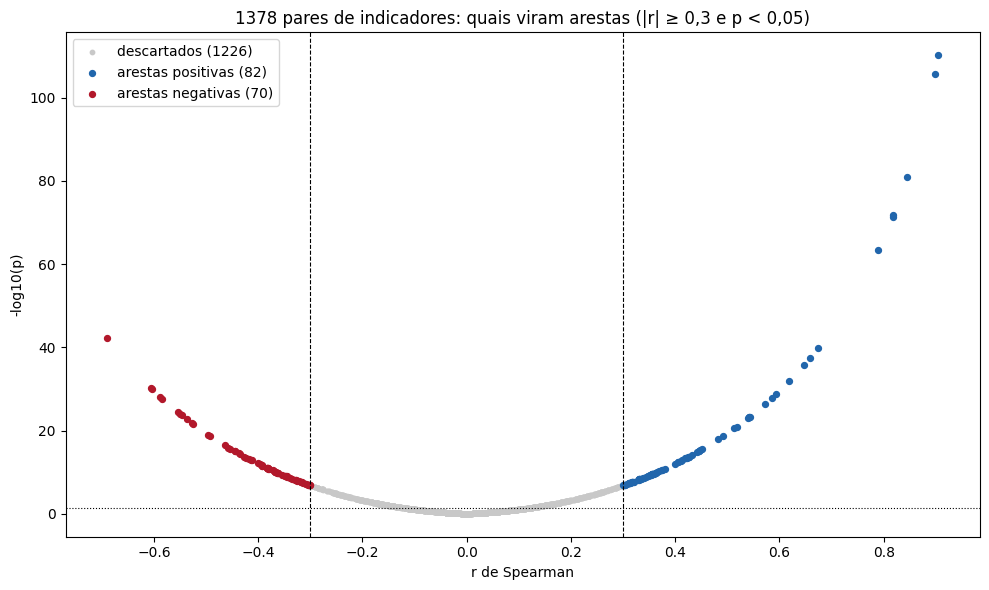

In [10]:
# filtro dos pares: magnitude × significância
logp = -np.log10(pares['p'].clip(lower=1e-300))
positivas = pares['aresta'] & (pares['r'] > 0)
negativas = pares['aresta'] & (pares['r'] < 0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(pares.loc[~pares['aresta'], 'r'], logp[~pares['aresta']], s=10, color='#c8c8c8',
           label=f'descartados ({(~pares["aresta"]).sum()})')
ax.scatter(pares.loc[positivas, 'r'], logp[positivas], s=18, color=COR_POSITIVA,
           label=f'arestas positivas ({positivas.sum()})')
ax.scatter(pares.loc[negativas, 'r'], logp[negativas], s=18, color=COR_NEGATIVA,
           label=f'arestas negativas ({negativas.sum()})')
for x in (-R_MIN, R_MIN):
    ax.axvline(x, color='black', linestyle='--', linewidth=0.8)
ax.axhline(-np.log10(P_MAX), color='black', linestyle=':', linewidth=0.8)
ax.set_xlabel('r de Spearman')
ax.set_ylabel('-log10(p)')
ax.set_title(f'{len(pares)} pares de indicadores: quais viram arestas (|r| ≥ 0,3 e p < 0,05)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT}/fig_filtro_pares.png', dpi=300)
plt.show()

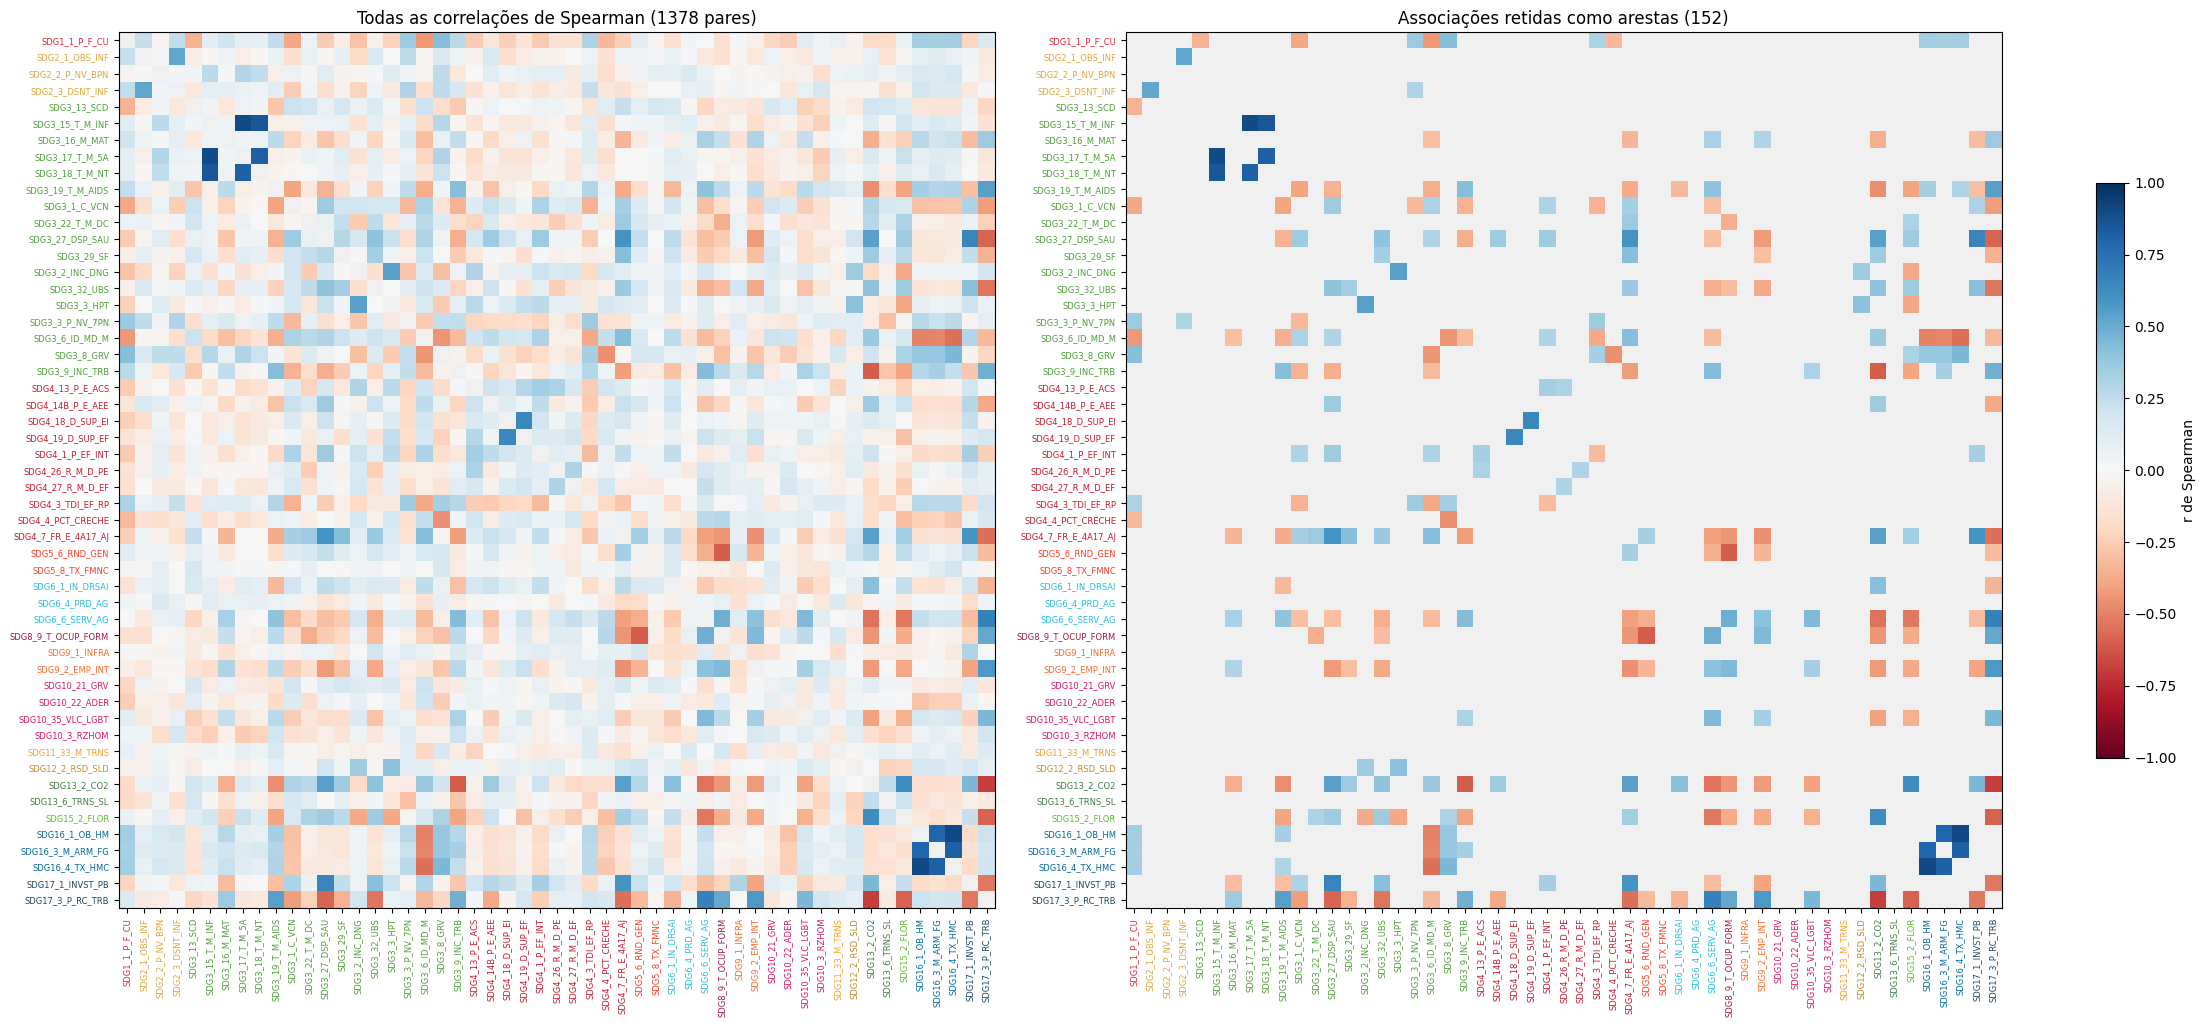

In [11]:
# matriz de correlação completa × apenas as associações retidas, ordenadas por ODS
ordem = sorted(indicadores_validos, key=lambda c: (ods_de[c], c))
M = pd.DataFrame(np.nan, index=ordem, columns=ordem)
M_ret = M.copy()
for e in pares.itertuples():
    M.loc[e.origem, e.destino] = M.loc[e.destino, e.origem] = e.r
    if e.aresta:
        M_ret.loc[e.origem, e.destino] = M_ret.loc[e.destino, e.origem] = e.r

cmap = plt.cm.RdBu.copy()
cmap.set_bad('#f0f0f0')

fig, axes = plt.subplots(1, 2, figsize=(22, 10.5), constrained_layout=True)
titulos = [f'Todas as correlações de Spearman ({len(pares)} pares)',
           f'Associações retidas como arestas ({pares["aresta"].sum()})']
for ax, dados, titulo in zip(axes, [M, M_ret], titulos):
    im = ax.imshow(dados.values.astype(float), cmap=cmap, vmin=-1, vmax=1)
    ax.set_xticks(range(len(ordem)))
    ax.set_yticks(range(len(ordem)))
    ax.set_xticklabels(ordem, rotation=90, fontsize=6)
    ax.set_yticklabels(ordem, fontsize=6)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_color(CORES_ODS[ods_de[lbl.get_text()]])
    ax.set_title(titulo)
fig.colorbar(im, ax=axes, shrink=0.6, label='r de Spearman')
plt.savefig(f'{OUTPUT}/fig_matriz_correlacoes.png', dpi=300)
plt.show()

In [12]:
# tabela das arestas, da associação mais forte para a mais fraca
arestas = pares[pares['aresta']].copy()
arestas['sinal'] = np.where(arestas['r'] > 0, 'positiva', 'negativa')
arestas['ODS_origem'] = arestas['origem'].map(ods_de)
arestas['ODS_destino'] = arestas['destino'].map(ods_de)
arestas['indicador_origem'] = arestas['origem'].map(nome_de)
arestas['indicador_destino'] = arestas['destino'].map(nome_de)
arestas = arestas.reindex(arestas['r'].abs().sort_values(ascending=False).index)

display(arestas[['ODS_origem', 'indicador_origem', 'ODS_destino', 'indicador_destino', 'r', 'p', 'sinal']]
        .round({'r': 3})
        .reset_index(drop=True))

,ODS_origem,indicador_origem,ODS_destino,indicador_destino,r,p,sinal
0,16,Homicídio juvenil masculino (100 mil habitantes),16,Taxa de homicídio (100 mil habitantes),0.905,7.102539e-111,positiva
1,3,Mortalidade na infância (número de óbitos infa...,3,Mortalidade infantil (crianças menores de 1 an...,0.898,2.197603e-106,positiva
2,3,Mortalidade neonatal (crianças de 0 a 27 dias)...,3,Mortalidade infantil (crianças menores de 1 an...,0.845,1.082662e-81,positiva
3,16,Taxa de homicídio (100 mil habitantes),16,Mortes por armas de fogo (100 mil habitantes),0.819,1.536298e-72,positiva
4,3,Mortalidade neonatal (crianças de 0 a 27 dias)...,3,Mortalidade na infância (número de óbitos infa...,0.817,4.183587e-72,positiva
...,...,...,...,...,...,...,...
147,6,População total atendida com abastecimento de ...,3,Cobertura vacinal (%),-0.302,1.249800e-07,negativa
148,9,Participação dos empregos formais em atividade...,3,População atendida por equipes de saúde da fam...,-0.301,1.323533e-07,negativa
149,16,Taxa de homicídio (100 mil habitantes),3,Mortalidade por Aids (100 mil habitantes),0.301,1.369756e-07,positiva
150,3,Idade média ao morrer,3,Mortalidade materna (mil nascidos vivos),-0.301,1.419539e-07,negativa


## 5. Construção e descrição da rede

In [13]:
def construir_rede(pares, nos):
    G = nx.Graph()
    for no in nos:
        G.add_node(no, ods=int(ods_de.get(no, 0)), label=nome_de.get(no, no))
    for e in pares[pares['aresta']].itertuples():
        G.add_edge(e.origem, e.destino,
                   weight=abs(e.r),
                   correlation=e.r,
                   sign='positiva' if e.r > 0 else 'negativa')
    return G


G = construir_rede(pares, indicadores_validos)
componentes = sorted(nx.connected_components(G), key=len, reverse=True)
isolados = list(nx.isolates(G))
G_main = G.subgraph(componentes[0]).copy()

print(f'Nós: {G.number_of_nodes()}')
print(f'Arestas: {G.number_of_edges()}')
print(f'Densidade: {nx.density(G):.4f}')
print(f'Componentes conectados: {len(componentes)} → tamanhos {[len(c) for c in componentes]}')
print(f'\nComponente principal: {G_main.number_of_nodes()} nós, '
      f'{G_main.number_of_edges()} arestas, densidade {nx.density(G_main):.4f}')

print(f'\nNós isolados ({len(isolados)}):')
for no in sorted(isolados, key=lambda n: ods_de[n]):
    print(f'  ODS {ods_de[no]} — {nome_de[no]}')

Nós: 53
Arestas: 152
Densidade: 0.1103
Componentes conectados: 12 → tamanhos [39, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Componente principal: 39 nós, 148 arestas, densidade 0.1997

Nós isolados (9):
  ODS 2 — Baixo peso ao nascer (%)
  ODS 5 — Taxa de feminicídio (100 mil mulheres)
  ODS 6 — Perda de água tratada na distribuição
  ODS 9 — Investimento público em infraestrutura urbana por habitante (R$ per capita)
  ODS 10 — Diferença na taxa de distorção idade-série nos anos iniciais do Ensino Fundamental entre PP e B
  ODS 10 — Diferença na taxa de homicídios entre PP e BA
  ODS 10 — Diferença na taxa de gravidez na adolescência entre mães PP e BA
  ODS 11 — Mortes no trânsito (100 mil habitantes)
  ODS 13 — Percentual do município desflorestado (%)


In [14]:
# grau e intermediação no componente principal
# intermediação sem peso: no networkx o peso seria lido como distância,
# o que tornaria as associações mais fortes caminhos mais longos
grau = dict(G_main.degree())
intermediacao = nx.betweenness_centrality(G_main, weight=None)

df_metricas = pd.DataFrame({'Arquivo': list(G_main.nodes())})
df_metricas['ODS'] = df_metricas['Arquivo'].map(ods_de)
df_metricas['Indicador'] = df_metricas['Arquivo'].map(nome_de)
df_metricas['grau'] = df_metricas['Arquivo'].map(grau)
df_metricas['grau_norm'] = df_metricas['Arquivo'].map(nx.degree_centrality(G_main))
df_metricas['intermediacao'] = df_metricas['Arquivo'].map(intermediacao)

print('=== TOP 15 POR INTERMEDIAÇÃO ===')
print(df_metricas.nlargest(15, 'intermediacao')[['ODS', 'Arquivo', 'Indicador', 'grau', 'intermediacao']]
      .round(4).to_string(index=False))

=== TOP 15 POR INTERMEDIAÇÃO ===
 ODS             Arquivo                                                                        Indicador  grau  intermediacao
  15        SDG15_2_FLOR                            Hectare de áreas florestadas e naturais por habitante    15         0.1952
   4     SDG4_1_P_EF_INT Acesso à internet nas escolas do ensino fundamental e médio, na rede pública (%)     6         0.1516
   3        SDG3_1_C_VCN                                                            Cobertura vacinal (%)    12         0.1508
   3      SDG3_6_ID_MD_M                                                            Idade média ao morrer    16         0.1405
   4     SDG4_13_P_E_ACS                 Escolas com dependências adequadas a pessoas com deficiência (%)     2         0.1024
   3     SDG3_3_P_NV_7PN                                                       Pré-natal insuficiente (%)     4         0.1024
   1       SDG1_1_P_F_CU                  Famílias inscritas no Cadastro Único

## 6. Comunidades (Louvain × 100) e comparação com redes aleatórias

In [15]:
# Louvain com peso = |r|, sementes 0 a 99
particoes = [community_louvain.best_partition(G_main, random_state=s, weight='weight')
             for s in range(N_LOUVAIN)]

nos = list(G_main.nodes())
rotulos = [[p[n] for n in nos] for p in particoes]
nmi = [normalized_mutual_info_score(rotulos[i], rotulos[j])
       for i in range(N_LOUVAIN) for j in range(i + 1, N_LOUVAIN)]

print(f'NMI entre as {N_LOUVAIN} execuções: média {np.mean(nmi):.4f}, '
      f'mínimo {np.min(nmi):.4f}, máximo {np.max(nmi):.4f}')
print('Número de comunidades por execução:')
print(pd.Series([len(set(p.values())) for p in particoes]).value_counts().sort_index().to_string())

# partição da semente 0
comunidade = {n: c + 1 for n, c in particoes[0].items()}
df_metricas['comunidade'] = df_metricas['Arquivo'].map(comunidade)

print(f'\n=== COMPOSIÇÃO DAS COMUNIDADES (semente 0) ===')
for c, grupo in df_metricas.sort_values(['comunidade', 'ODS']).groupby('comunidade'):
    print(f'\nComunidade {c} ({len(grupo)} indicadores):')
    for linha in grupo.itertuples():
        print(f'  ODS {linha.ODS} — {linha.Indicador[:70]}')

NMI entre as 100 execuções: média 0.9072, mínimo 0.5696, máximo 1.0000
Número de comunidades por execução:
4    31
5    69

=== COMPOSIÇÃO DAS COMUNIDADES (semente 0) ===

Comunidade 1 (14 indicadores):
  ODS 1 — Famílias inscritas no Cadastro Único para programas sociais (%)
  ODS 2 — Obesidade infantil (%)
  ODS 2 — Desnutrição infantil (%)
  ODS 3 — Pré-natal insuficiente (%)
  ODS 3 — Gravidez na adolescência (%)
  ODS 3 — Idade média ao morrer
  ODS 3 — Mortalidade por suicídio (100 mil habitantes)
  ODS 3 — Cobertura vacinal (%)
  ODS 4 — Acesso à internet nas escolas do ensino fundamental e médio, na rede p
  ODS 4 — Taxa de distorção idade-série no Ensino Fundamental - rede pública
  ODS 4 — Percentual de crianças de 0 a 3 anos matrículadas em creches
  ODS 16 — Homicídio juvenil masculino (100 mil habitantes)
  ODS 16 — Taxa de homicídio (100 mil habitantes)
  ODS 16 — Mortes por armas de fogo (100 mil habitantes)

Comunidade 2 (3 indicadores):
  ODS 3 — Incidência de dengue (

Redes aleatórias conectadas (usadas no caminho médio): 991 de 1000

Clusterização média — empírica: 0.5957 | aleatória: 0.1995 | razão: 2.99
Caminho médio — empírico: 2.5816 | aleatório: 1.9783 | razão: 1.30
Diâmetro do componente principal: 7


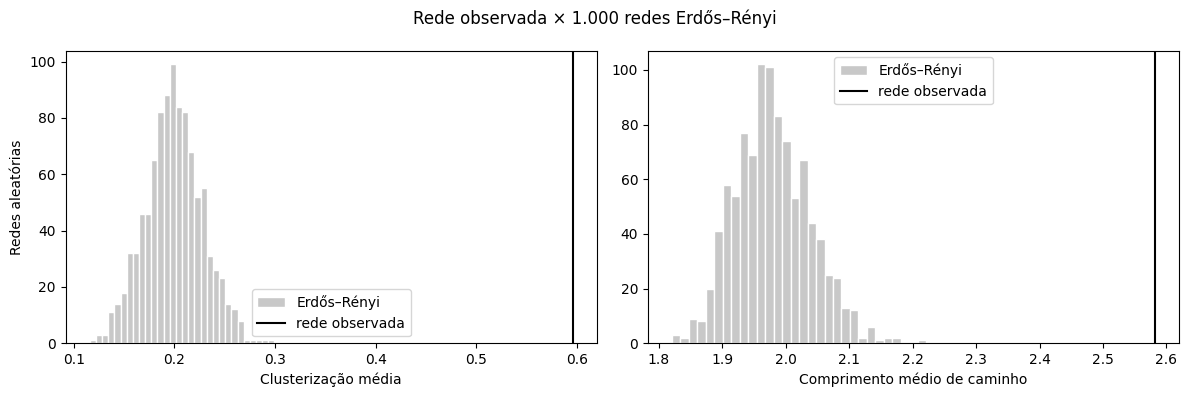

In [16]:
# 1.000 redes Erdős–Rényi com o mesmo número de nós e a densidade do componente principal
n_nos = G_main.number_of_nodes()
densidade = nx.density(G_main)
cc_emp = nx.average_clustering(G_main)
apl_emp = nx.average_shortest_path_length(G_main)

cc_rand, apl_rand = [], []
for s in range(N_ALEATORIAS):
    G_r = nx.erdos_renyi_graph(n_nos, densidade, seed=s)
    cc_rand.append(nx.average_clustering(G_r))
    if nx.is_connected(G_r):
        apl_rand.append(nx.average_shortest_path_length(G_r))

print(f'Redes aleatórias conectadas (usadas no caminho médio): {len(apl_rand)} de {N_ALEATORIAS}')
print(f'\nClusterização média — empírica: {cc_emp:.4f} | aleatória: {np.mean(cc_rand):.4f} '
      f'| razão: {cc_emp / np.mean(cc_rand):.2f}')
print(f'Caminho médio — empírico: {apl_emp:.4f} | aleatório: {np.mean(apl_rand):.4f} '
      f'| razão: {apl_emp / np.mean(apl_rand):.2f}')
print(f'Diâmetro do componente principal: {nx.diameter(G_main)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, dist, emp, rotulo in [(axes[0], cc_rand, cc_emp, 'Clusterização média'),
                              (axes[1], apl_rand, apl_emp, 'Comprimento médio de caminho')]:
    ax.hist(dist, bins=30, color='#c8c8c8', edgecolor='white', label='Erdős–Rényi')
    ax.axvline(emp, color='black', linewidth=1.5, label='rede observada')
    ax.set_xlabel(rotulo)
    ax.legend()
axes[0].set_ylabel('Redes aleatórias')
plt.suptitle('Rede observada × 1.000 redes Erdős–Rényi')
plt.tight_layout()
plt.savefig(f'{OUTPUT}/fig_erdos_renyi.png', dpi=300)
plt.show()

## 7. Teste de sensibilidade do limite de cobertura

In [17]:
# incluir o indicador imediatamente abaixo de 57% e verificar o componente principal
f = fronteira['Arquivo']
cols_sens = indicadores_validos + [f]
df_mun_sens = df_sc[['ID'] + cols_sens].groupby('ID').mean()
pares_sens = correlacoes_spearman(df_mun_sens)
G_sens = construir_rede(pares_sens, cols_sens)
G_sens_main = G_sens.subgraph(max(nx.connected_components(G_sens), key=len))

novas = pares_sens[pares_sens['aresta'] & ((pares_sens['origem'] == f) | (pares_sens['destino'] == f))]
comp_f = nx.node_connected_component(G_sens, f)

print(f'Indicador testado: {f} — {nome_de[f]} ({fronteira["cobertura"]:.2%})')
print(f'Arestas do indicador: {len(novas)}')
for e in novas.itertuples():
    outro = e.destino if e.origem == f else e.origem
    print(f'  ↔ {outro} (r = {e.r:.3f})')
print(f'Componente em que entra: {len(comp_f)} nós; é o principal? {f in G_sens_main}')
print(f'Componente principal inalterado (nós): {set(G_sens_main) == set(G_main)}')
print(f'Componente principal inalterado (arestas): '
      f'{set(map(frozenset, G_sens_main.edges())) == set(map(frozenset, G_main.edges()))}')

Indicador testado: SDG10_20_MINF — Diferença na taxa de mortalidade infantil entre crianças nascidas de mães PP e BA (54.38%)
Arestas do indicador: 2
  ↔ SDG3_17_T_M_5A (r = -0.340)
  ↔ SDG3_15_T_M_INF (r = -0.323)
Componente em que entra: 4 nós; é o principal? False
Componente principal inalterado (nós): True
Componente principal inalterado (arestas): True


## 8. Visualização da rede — prova de conceito

- **Nós**: indicadores; tamanho proporcional à intermediação
- **Arestas**: azul = associação positiva, vermelho tracejado = negativa; espessura proporcional a |r|
- Componentes secundários e nós isolados aparecem na faixa inferior

In [18]:
def layout_rede(G, G_main, seed=SEED_LAYOUT):
    pos = nx.spring_layout(G_main, weight='weight', seed=seed, k=0.6, iterations=300)
    # esticar o componente principal para ocupar o quadro [-1, 1] nos dois eixos
    xy = np.array(list(pos.values()))
    xy = 2 * (xy - xy.min(axis=0)) / (xy.max(axis=0) - xy.min(axis=0)) - 1
    pos = dict(zip(pos.keys(), xy))
    # componentes secundários e isolados em uma faixa abaixo do principal
    outros = sorted((c for c in nx.connected_components(G) if not c & set(G_main)),
                    key=len, reverse=True)
    x = -1.0
    for comp in outros:
        sub = nx.spring_layout(G.subgraph(comp), seed=seed, scale=0.08)
        for n, (dx, dy) in sub.items():
            pos[n] = np.array([x + dx, -1.35 + dy])
        x += 0.35 if len(comp) > 1 else 0.2
    return pos


def desenhar_rede(G, pos, cores, titulo, legenda, arquivo):
    fig, ax = plt.subplots(figsize=(17, 14))
    for sinal, cor, estilo in [('positiva', COR_POSITIVA, 'solid'), ('negativa', COR_NEGATIVA, 'dashed')]:
        es = [(u, v) for u, v, d in G.edges(data=True) if d['sign'] == sinal]
        nx.draw_networkx_edges(G, pos, edgelist=es, ax=ax, edge_color=cor, style=estilo, alpha=0.55,
                               width=[0.6 + 6 * (G[u][v]['weight'] - R_MIN) for u, v in es])
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_color=[cores[n] for n in G],
                           node_size=[180 + 4000 * intermediacao.get(n, 0) for n in G],
                           edgecolors=['black' if n in isolados else 'white' for n in G],
                           linewidths=0.8)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=6.5,
                            labels={n: n.replace('SDG', '') for n in G})
    ax.axhline(-1.2, color='#dddddd', linewidth=0.8)
    ax.text(-1.0, -1.23, 'componentes secundários e nós isolados', fontsize=9, color='gray', va='top')
    arestas_leg = [Line2D([0], [0], color=COR_POSITIVA, lw=2, label='associação positiva'),
                   Line2D([0], [0], color=COR_NEGATIVA, lw=2, ls='--', label='associação negativa')]
    ax.legend(handles=legenda + arestas_leg, loc='upper left', fontsize=9, frameon=False)
    ax.set_title(titulo, fontsize=14)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT}/{arquivo}', dpi=300)
    plt.show()


pos = layout_rede(G, G_main)

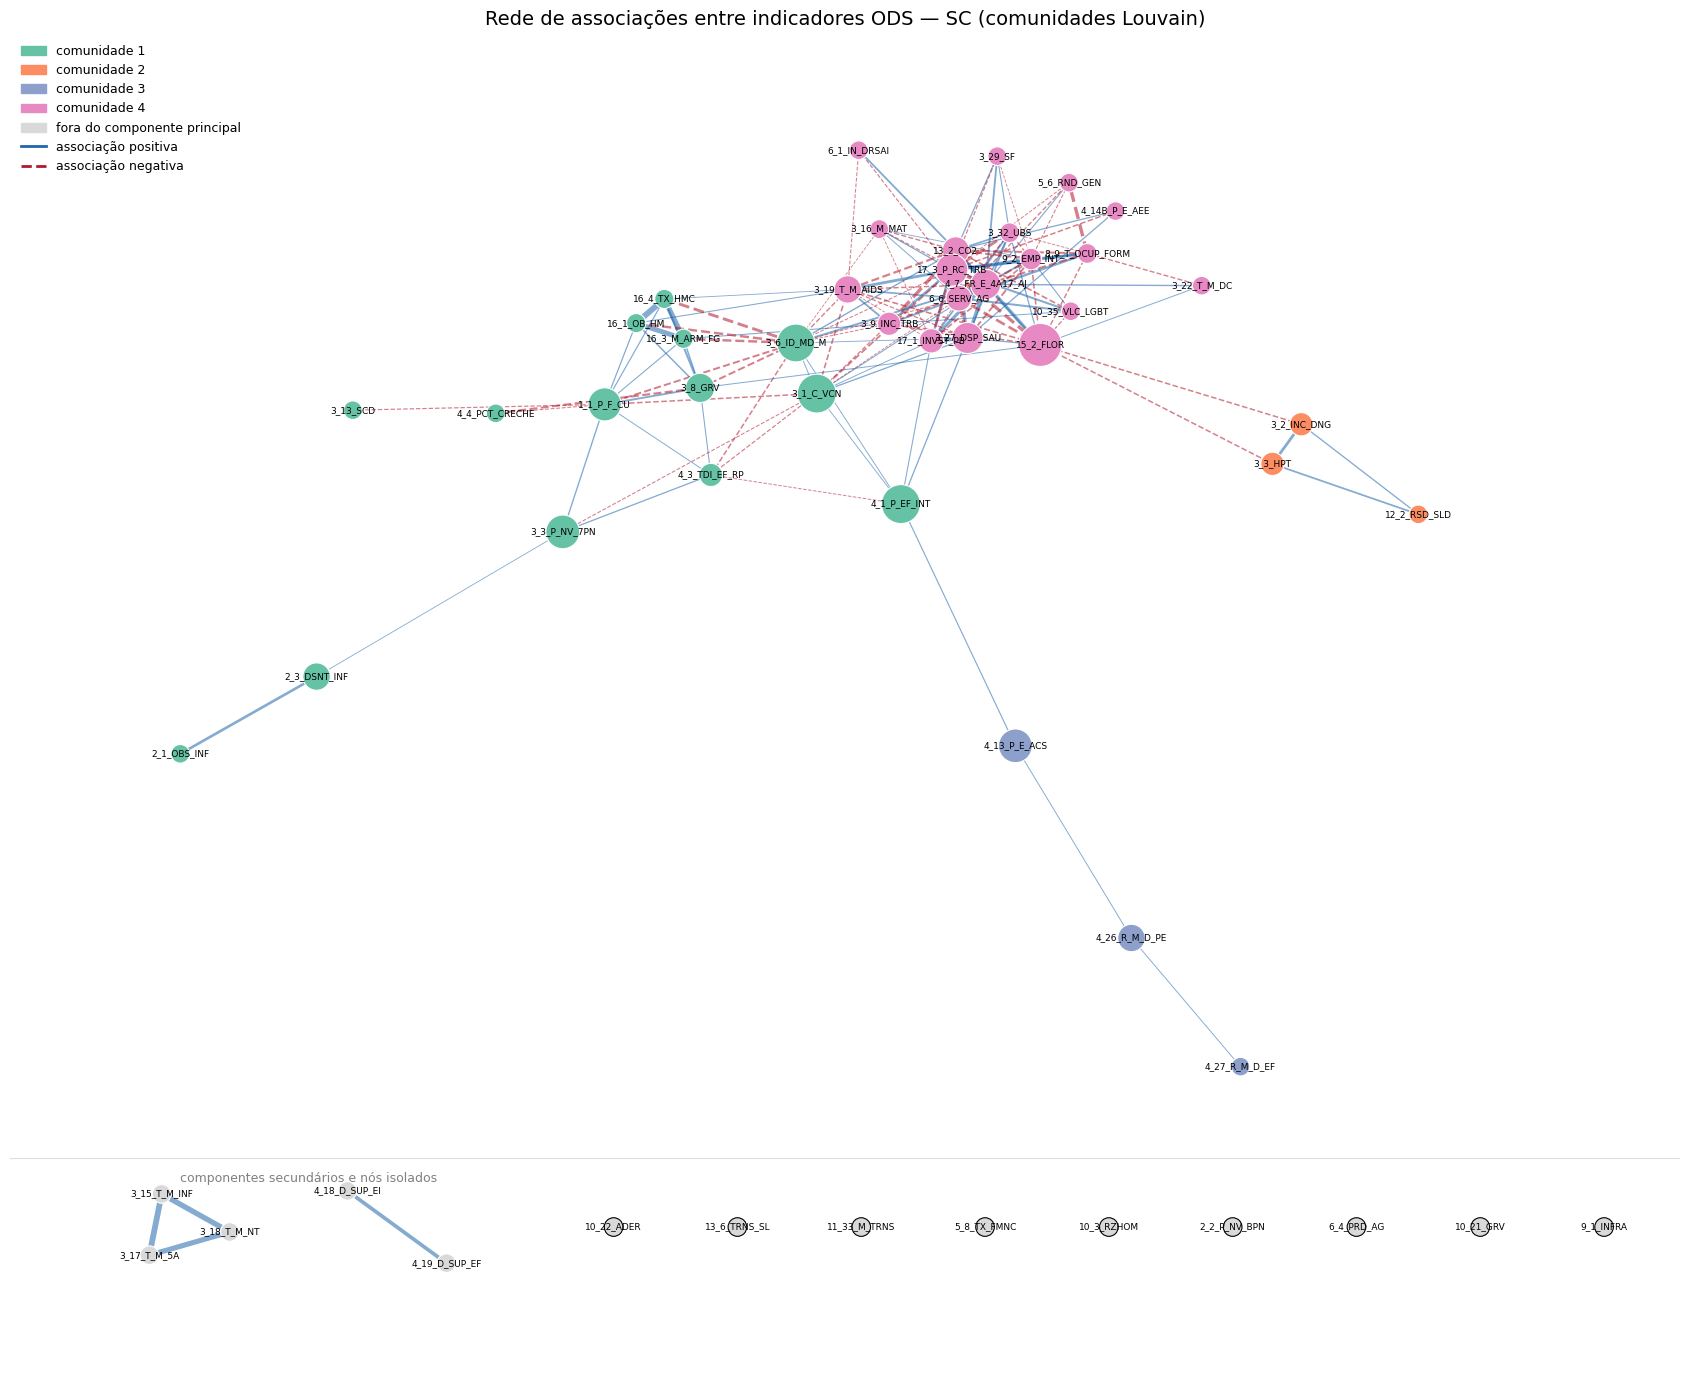

In [19]:
# cores por comunidade Louvain
paleta = plt.cm.Set2.colors
cores_com = {n: paleta[(comunidade[n] - 1) % len(paleta)] if n in comunidade else '#d9d9d9' for n in G}
leg_com = [Patch(color=paleta[(c - 1) % len(paleta)], label=f'comunidade {c}')
           for c in sorted(set(comunidade.values()))]
leg_com.append(Patch(color='#d9d9d9', label='fora do componente principal'))

desenhar_rede(G, pos, cores_com,
              'Rede de associações entre indicadores ODS — SC (comunidades Louvain)',
              leg_com, 'fig_rede_comunidades.png')

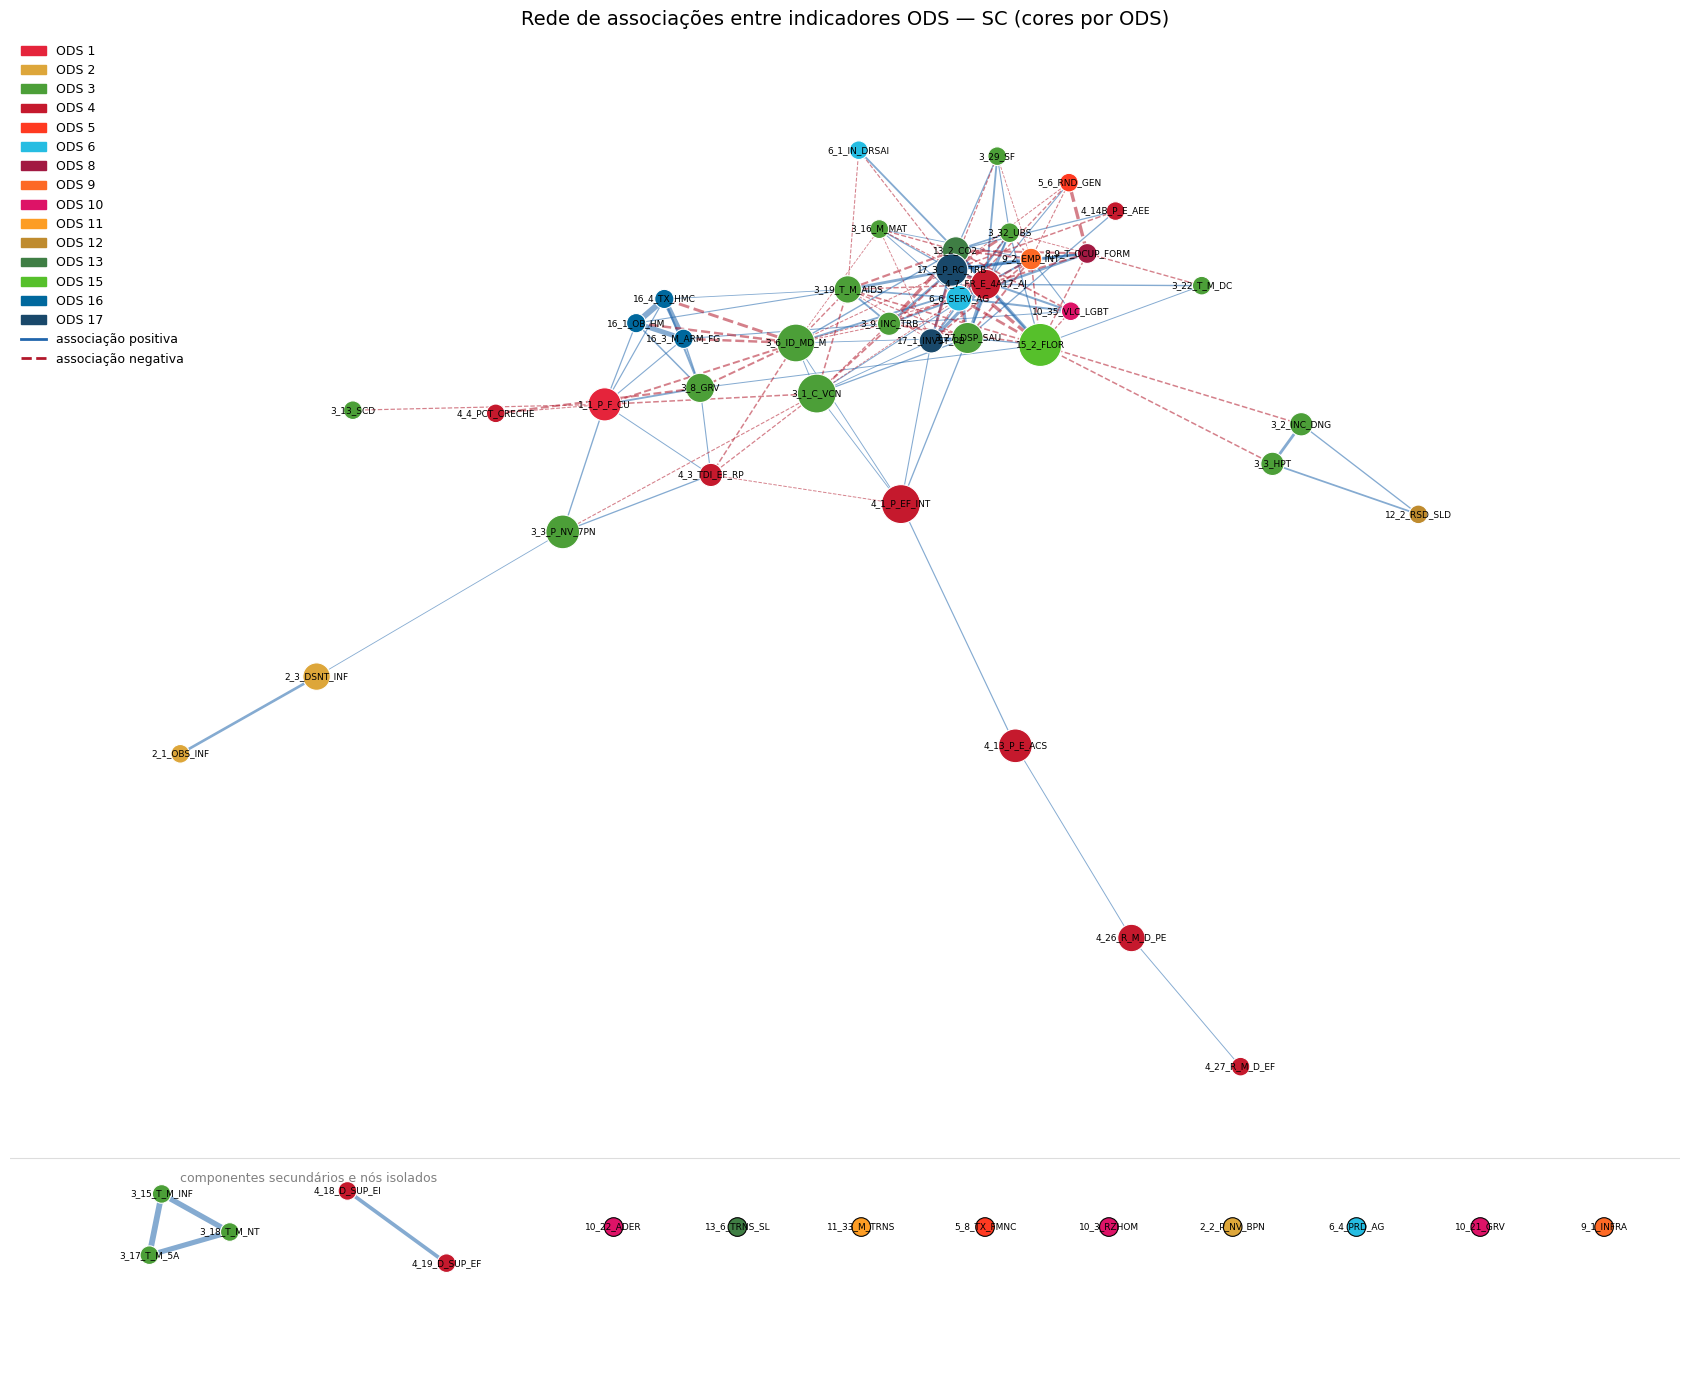

In [20]:
# mesma rede, cores oficiais dos ODS — permite comparar comunidades com a classificação temática
cores_ods = {n: CORES_ODS[ods_de[n]] for n in G}
leg_ods = [Patch(color=CORES_ODS[o], label=f'ODS {o}') for o in sorted({ods_de[n] for n in G})]

desenhar_rede(G, pos, cores_ods,
              'Rede de associações entre indicadores ODS — SC (cores por ODS)',
              leg_ods, 'fig_rede_ods.png')

In [21]:
# versão interativa: arraste nós, passe o mouse para ver indicador, ODS, grau e r
from pyvis.network import Network
from IPython.display import HTML, display

net = Network(height='750px', width='100%', bgcolor='#ffffff', cdn_resources='in_line')
for n in G:
    net.add_node(n, label=n.replace('SDG', ''),
                 title=(f'{nome_de[n]}\nODS {ods_de[n]} | comunidade {comunidade.get(n, "-")}'
                        f'\ngrau {G.degree(n)} | intermediação {intermediacao.get(n, 0):.3f}'),
                 color=CORES_ODS[ods_de[n]],
                 size=10 + 60 * intermediacao.get(n, 0))
for u, v, d in G.edges(data=True):
    net.add_edge(u, v, value=d['weight'], title=f'r = {d["correlation"]:.3f}',
                 color=COR_POSITIVA if d['sign'] == 'positiva' else COR_NEGATIVA,
                 dashes=d['sign'] == 'negativa')
net.barnes_hut(spring_length=140)

html = net.generate_html()
with open(f'{OUTPUT}/rede_indicadores_ods_sc.html', 'w', encoding='utf-8') as arq:
    arq.write(html)
display(HTML(html))

## 9. Exportação

In [22]:
# atributos para o Gephi
for n in G:
    G.nodes[n]['comunidade'] = comunidade.get(n, 0)
    G.nodes[n]['grau'] = G.degree(n)
    G.nodes[n]['intermediacao'] = float(intermediacao.get(n, 0))
    G.nodes[n]['componente_principal'] = n in G_main
    G.nodes[n]['isolado'] = n in isolados
nx.write_gexf(G, f'{OUTPUT}/rede_indicadores_ods_sc.gexf')

df_final.to_csv(f'{OUTPUT}/base_sc_filtrada.csv', index=False)
cobertura.to_csv(f'{OUTPUT}/relatorio_cobertura.csv', index=False)
cobertura[cobertura['selecionado']].to_csv(f'{OUTPUT}/indicadores_selecionados.csv', index=False)
cobertura[~cobertura['selecionado']].to_csv(f'{OUTPUT}/lacunas_informacionais.csv', index=False)
pares.to_csv(f'{OUTPUT}/pares_spearman.csv', index=False)
arestas.to_csv(f'{OUTPUT}/arestas_rede.csv', index=False)
df_metricas.to_csv(f'{OUTPUT}/metricas_topologicas.csv', index=False)

estado = {
    'G': G, 'G_main': G_main, 'comunidade': comunidade, 'particoes': particoes,
    'df_metricas': df_metricas, 'df_municipio': df_municipio, 'pares': pares,
    'indicadores_validos': indicadores_validos, 'isolados': isolados, 'pos': pos
}
with open(f'{OUTPUT}/estado_analise.pkl', 'wb') as arq:
    pickle.dump(estado, arq)

print(f'Arquivos salvos em {OUTPUT}:')
for nome in sorted(os.listdir(OUTPUT)):
    print(f'  {nome}')

Arquivos salvos em /content/drive/MyDrive/Mestrado/outputs:
  arestas_rede.csv
  base_sc_filtrada.csv
  estado_analise.pkl
  fig_cobertura.png
  fig_erdos_renyi.png
  fig_filtro_pares.png
  fig_matriz_correlacoes.png
  fig_rede_comunidades.png
  fig_rede_ods.png
  indicadores_selecionados.csv
  lacunas_informacionais.csv
  metricas_topologicas.csv
  pares_spearman.csv
  rede_indicadores_ods_sc.gexf
  rede_indicadores_ods_sc.html
  relatorio_cobertura.csv


In [23]:
print('=== RESUMO ===')
print(f'Municípios: {len(df_municipio)} | indicadores na rede: {G.number_of_nodes()}')
print(f'Arestas: {G.number_of_edges()} ({positivas.sum()} positivas, {negativas.sum()} negativas)')
print(f'Componente principal: {G_main.number_of_nodes()} nós, {G_main.number_of_edges()} arestas, '
      f'densidade {nx.density(G_main):.4f}')
print(f'Nós isolados: {len(isolados)}')
print(f'Comunidades (semente 0): {len(set(comunidade.values()))} | NMI médio: {np.mean(nmi):.4f}')
print(f'Razão de clusterização: {cc_emp / np.mean(cc_rand):.2f} | '
      f'razão de caminho médio: {apl_emp / np.mean(apl_rand):.2f}')

=== RESUMO ===
Municípios: 295 | indicadores na rede: 53
Arestas: 152 (82 positivas, 70 negativas)
Componente principal: 39 nós, 148 arestas, densidade 0.1997
Nós isolados: 9
Comunidades (semente 0): 4 | NMI médio: 0.9072
Razão de clusterização: 2.99 | razão de caminho médio: 1.30
